In [2]:
%load_ext autoreload
%autoreload 2

import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src import config as cfg, data, adaboost, evaluation as ev

splits = {name: data.get_split(name) for name in cfg.DATASETS}
with open(cfg.RESULTS_DIR / f"hyperparams_seed{cfg.SEED}.json") as f:
    best = json.load(f)
LIM = {"oblique": 3.0, "circles": 1.7}

CLASS_STYLE = {1: dict(c="tab:blue", marker="o", label="$y = +1$"),
               -1: dict(c="tab:orange", marker="x", label="$y = -1$")}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
models, curves = {}, {} 
for name, s in splits.items():
    t0=time.perf_counter()
    m = adaboost.fit(s["X_train"], s["y_train"], cfg.T_MAX, store_weights=True)
    train = adaboost.staged_errors(m, s["X_train"], s["y_train"], cfg.T_MAX)
    test = adaboost.staged_errors(m, s["X_test"], s["y_test"], cfg.T_MAX)
    models[name], curves[name] = m, (train, test)
    np.savez(cfg.RESULTS_DIR / f"adaboost_{name}_seed{cfg.SEED}.npz", train=train, test=test, **m)
    T = best[name]["T"]
    print(f"{name}: T* = {T}, train {train[T-1]:.3f} / test {test[T-1]:.3f}; "
          f"T = {cfg.T_MAX}: train {train[-1]:.3f} / test {test[-1]:.3f} ({time.perf_counter()-t0:.1f}s)")

spambase: T* = 54, train 0.055 / test 0.057; T = 500: train 0.042 / test 0.061 (2.6s)
oblique: T* = 54, train 0.130 / test 0.172; T = 500: train 0.117 / test 0.184 (0.1s)
circles: T* = 122, train 0.137 / test 0.156; T = 500: train 0.131 / test 0.164 (0.1s)


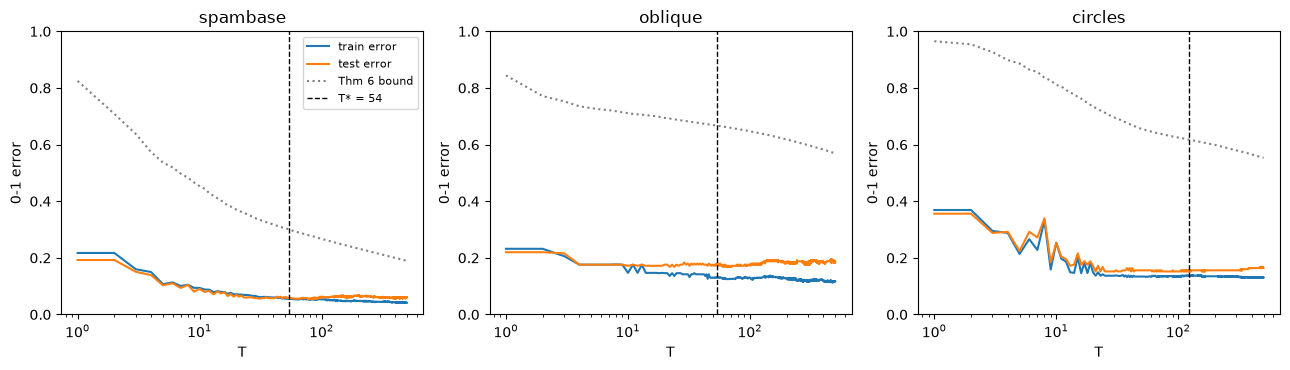

In [4]:
t = np.arange(1, cfg.T_MAX+1)
fig, axes= plt.subplots(1,3,figsize=(13,3.8))
for ax, name in zip(axes, cfg.DATASETS):
    train, test = curves[name]
    eps = models[name]["eps"]
    ax.plot(t, train, label="train error")
    ax.plot(t, test, label="test error")
    ax.plot(np.arange(1, len(eps)+1), np.cumprod(2*np.sqrt(eps*(1-eps))), ls=":", color="gray", label="Thm 6 bound")
    ax.axvline(best[name]["T"], color="k", ls="--", lw=1, label=f"T* = {best[name]['T']}")
    ax.set(xscale="log", ylim=(0,1), title=name, xlabel="T", ylabel="0-1 error")

axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "adaboost_curves.pdf", bbox_inches="tight")
plt.show()

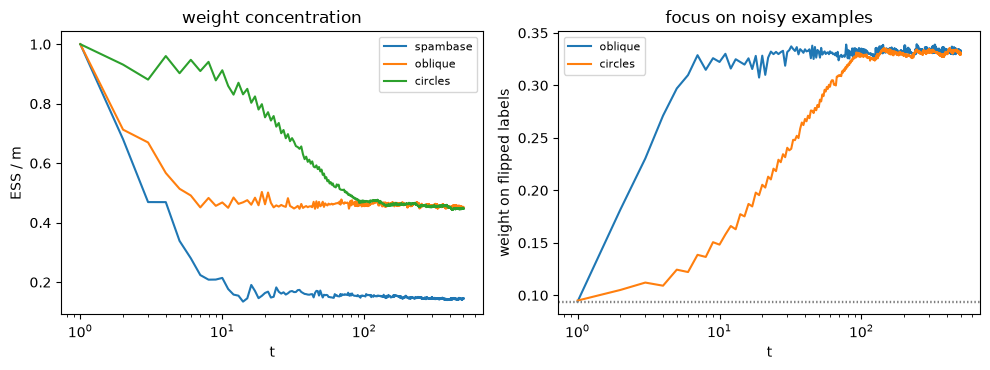

In [5]:
fig, axes = plt.subplots(1,2,figsize=(10,3.8))
for name in cfg.DATASETS:
    W = models[name]["weights"]
    axes[0].plot(np.arange(1, len(W)+1), ev.effective_size(W)/W.shape[1], label=name)

for name in ("oblique", "circles"):
    s, W = splits[name], models[name]["weights"]
    flip = s["y_train"] != s["yclean_train"]
    axes[1].plot(np.arange(1,len(W)+1), ev.weight_share(W, flip), label=name)
    axes[1].axhline(flip.mean(), color="gray", ls=":", lw=1)

axes[0].set(xscale="log", xlabel="t", ylabel="ESS / m", title="weight concentration")
axes[1].set(xscale="log", xlabel="t", ylabel="weight on flipped labels", title="focus on noisy examples")

for ax in axes:
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "weight_stats.pdf", bbox_inches="tight")
plt.show()
    

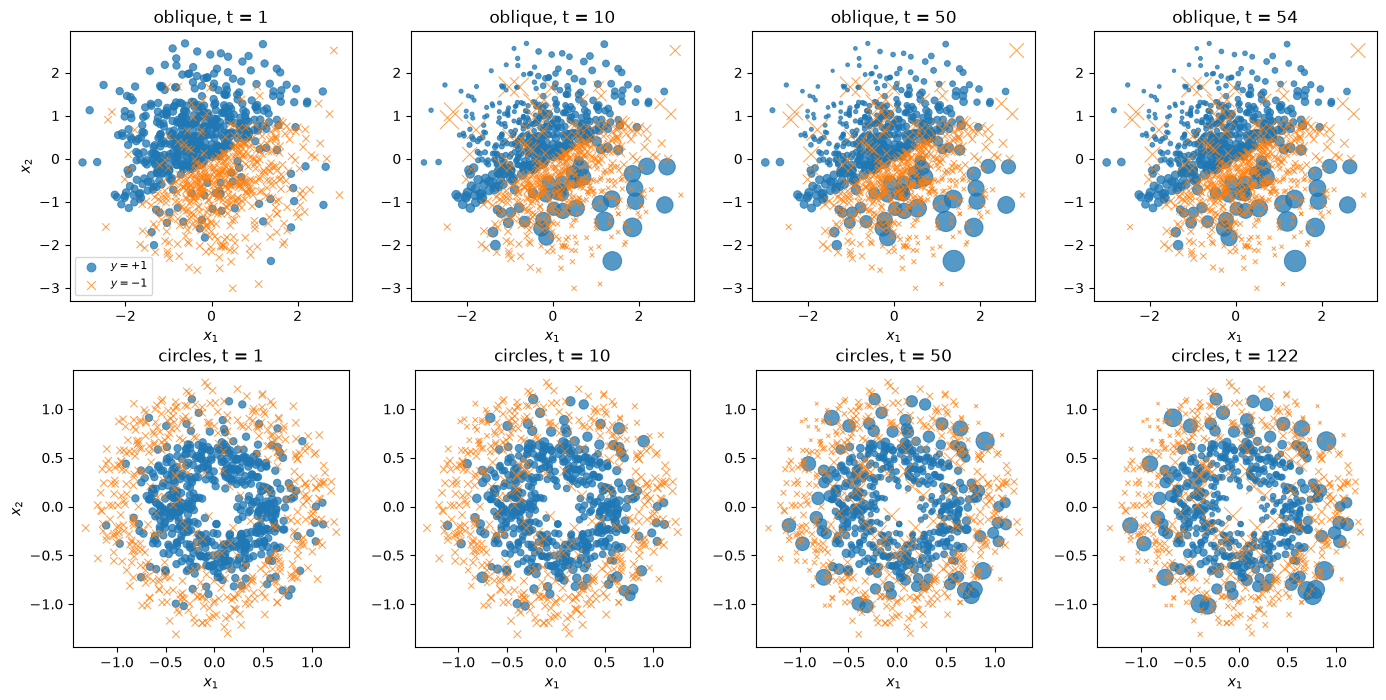

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, name in zip(axes, ("oblique", "circles")):
    s, W = splits[name], models[name]["weights"]
    X, y = s["X_train"], s["y_train"]
    for ax, r in zip(row, [1, 10, 50, best[name]["T"]]):
        size = 3 + 25 * W[r - 1] * len(y)            
        for c, st in CLASS_STYLE.items():
            sel = y == c
            ax.scatter(*X[sel].T, s=size[sel], alpha=0.75, lw=0.7, **st)
        ax.set(title=f"{name}, t = {r}", aspect="equal", xlabel="$x_1$")
    row[0].set_ylabel("$x_2$")
axes[0, 0].legend(loc="lower left", fontsize=8, markerscale=1.2)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "weight_scatter.pdf", bbox_inches="tight")
plt.show()

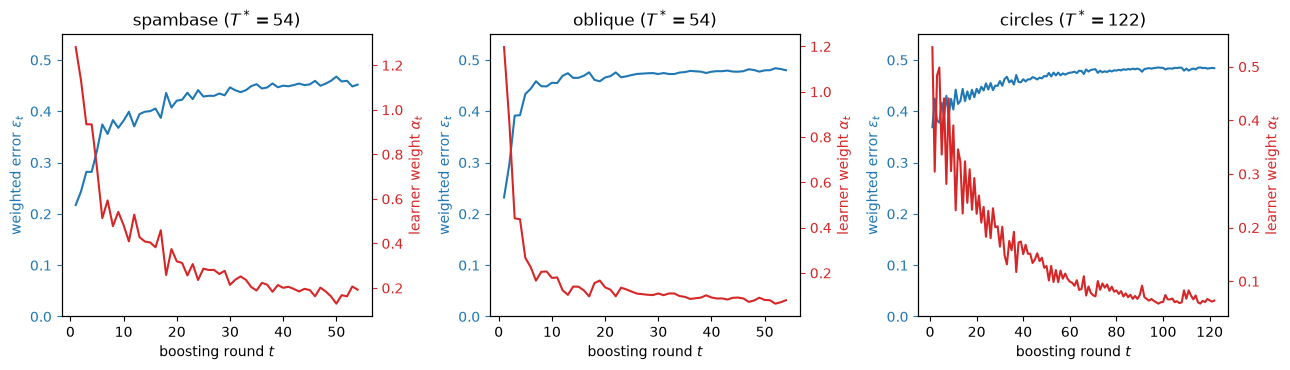

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, name in zip(axes, cfg.DATASETS):
    m, T = models[name], best[name]["T"]
    tt = np.arange(1, T + 1)
    ax.plot(tt, m["eps"][:T], color="tab:blue")
    ax.set(title=f"{name} ($T^* = {T}$)", xlabel="boosting round $t$", ylim=(0, 0.55))
    ax.set_ylabel(r"weighted error $\varepsilon_t$", color="tab:blue")
    ax.tick_params(axis="y", colors="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(tt, m["alpha"][:T], color="tab:red")
    ax2.set_ylabel(r"learner weight $\alpha_t$", color="tab:red")
    ax2.tick_params(axis="y", colors="tab:red")
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "learner_contribution.pdf", bbox_inches="tight")
plt.show()

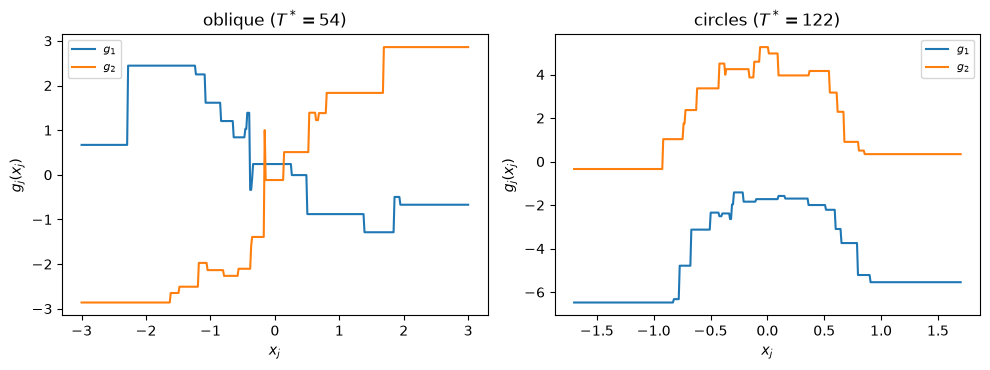

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, name in zip(axes, ("oblique", "circles")):
    sub = adaboost.truncate(models[name], best[name]["T"])
    g = np.linspace(-LIM[name], LIM[name], 400)
    for j in (0, 1):
        ax.plot(g, ev.additive_component(sub, j, g), label=f"$g_{j+1}$")
    ax.set(title=f"{name} ($T^* = {best[name]['T']}$)", xlabel="$x_j$", ylabel="$g_j(x_j)$")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "additive_components.pdf", bbox_inches="tight")
plt.show()

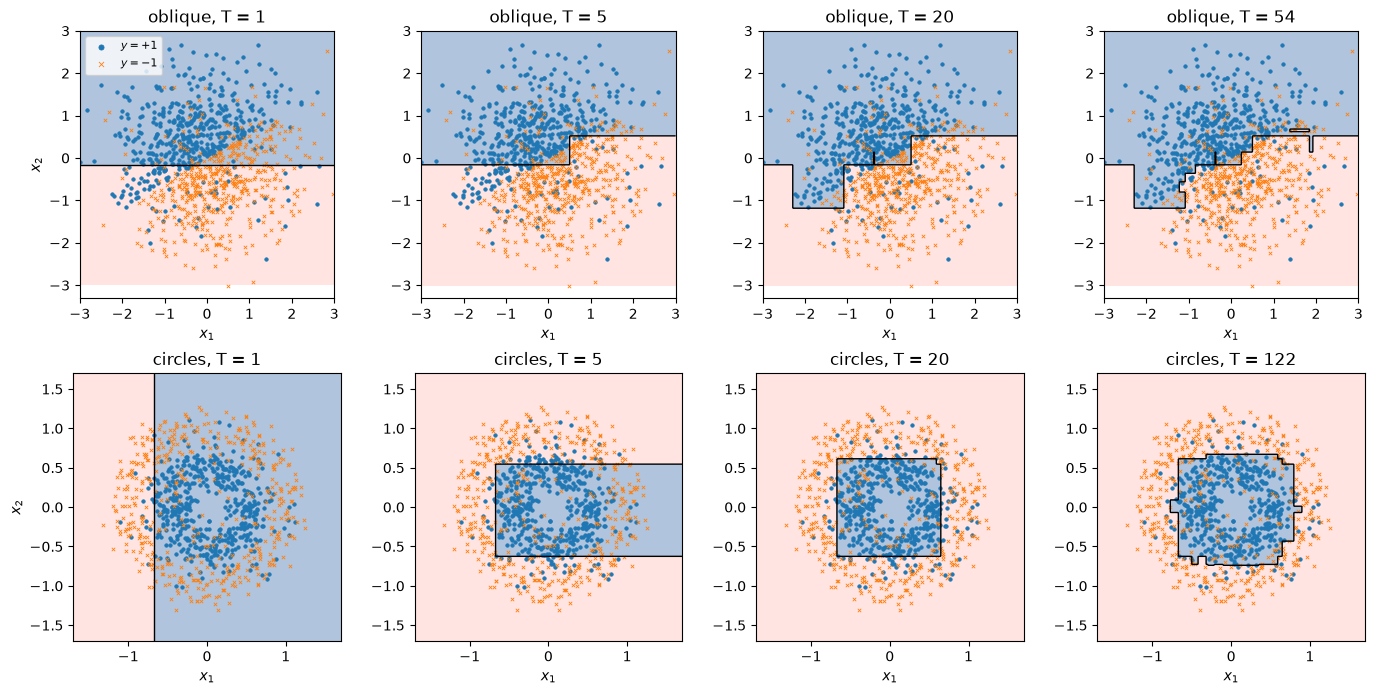

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, name in zip(axes, ("oblique", "circles")):
    s, m, lim = splits[name], models[name], LIM[name]
    g = np.linspace(-lim, lim, 300)
    G1, G2 = np.meshgrid(g, g)
    grid = np.c_[G1.ravel(), G2.ravel()]
    for ax, T in zip(row, [1, 5, 20, best[name]["T"]]):
        Z = np.sign(adaboost.score(m, grid, T)).reshape(G1.shape)
        ax.contourf(G1, G2, Z, levels=[-2, 0, 2], colors=["mistyrose", "lightsteelblue"])
        ax.contour(G1, G2, Z, levels=[0], colors="k", linewidths=1)
        for c, st in CLASS_STYLE.items():
            ax.scatter(*s["X_train"][s["y_train"] == c].T, s=6, lw=0.6, **st)
        ax.set(title=f"{name}, T = {T}", aspect="equal", xlabel="$x_1$")
    row[0].set_ylabel("$x_2$")
axes[0, 0].legend(loc="upper left", fontsize=8, markerscale=1.5)
fig.tight_layout()
fig.savefig(cfg.FIG_DIR / "boundary_evolution.pdf", bbox_inches="tight")
plt.show()